In [5]:
import pandas as pd

df = pd.read_csv('files/DEFINITIVE_ALL_AVCS_PREDICTION.csv')
unique_combinations = df[['data', 'subcarpeta', 'carpeta paciente', 'echo']].drop_duplicates()


In [6]:
unique_combinations

,data,subcarpeta,carpeta paciente,echo
0,data_psax,basal,10_001,IM_0017
1,data_psax,basal,10_003,IM_0012
2,data_psax,basal,10_003,IM_0013
3,data_psax,basal,10_004,IM_0014
4,data_psax,basal,10_006,IM_0012
...,...,...,...,...
2771,data_3ch,24m,7_003,015
2772,data_3ch,24m,7_004,014
2773,data_3ch,24m,7_008,005
2774,data_3ch,24m,7_009,013


In [12]:
import pandas as pd
import ast

# Load the adjusted CSV into a DataFrame
df = pd.read_csv('files/DEFINITIVE_ALL_AVCS_PREDICTION.csv')

# Convert p1_new and p2_new from strings to tuples
df['p1_new'] = df['p1_new'].apply(ast.literal_eval)
df['p2_new'] = df['p2_new'].apply(ast.literal_eval)

# Function to adjust the width and height to at least 128 pixels
def adjust_to_min_128(p1, p2):
    width = abs(p2[0] - p1[0])
    height = abs(p2[1] - p1[1])

    # Adjust width if less than 128
    if width < 128:
        width_diff = 128 - width
        p1_new_x = p1[0] - width_diff // 2
        p2_new_x = p2[0] + width_diff // 2

        # In case of odd difference, adjust one side by one extra pixel
        if width_diff % 2 != 0:
            p2_new_x += 1  # Add remaining pixel to p2 (right side)

        p1 = (p1_new_x, p1[1])
        p2 = (p2_new_x, p2[1])

    # Adjust height if less than 128
    if height < 128:
        height_diff = 128 - height
        p1_new_y = p1[1] + height_diff // 2
        p2_new_y = p2[1] - height_diff // 2

        # In case of odd difference, adjust one side by one extra pixel
        if height_diff % 2 != 0:
            p2_new_y -= 1  # Add remaining pixel to p2 (bottom side)

        p1 = (p1[0], p1_new_y)
        p2 = (p2[0], p2_new_y)

    return p1, p2

# Iterate over the DataFrame and adjust for cases where width or height is less than 128
for idx, row in df.iterrows():
    p1 = row['p1_new']
    p2 = row['p2_new']

    # Omit cases where p1 or p2 are (-1, -1)
    if p1 == (-1, -1) or p2 == (-1, -1):
        continue

    # Calculate width and height
    width = abs(p2[0] - p1[0])
    height = abs(p2[1] - p1[1])

    # Adjust if width or height is less than 128
    if width < 128 or height < 128:
        p1_new, p2_new = adjust_to_min_128(p1, p2)
        
        # Calculate new width and height after adjustment
        new_width = abs(p2_new[0] - p1_new[0])
        new_height = abs(p2_new[1] - p1_new[1])
        
        # Print the old and new coordinates, width, and height
        print(f"Old p1: {p1}, Old p2: {p2}, New p1: {p1_new}, New p2: {p2_new}, Old width: {width}, Old height: {height}, New width: {new_width}, New height: {new_height}")
        
        # Update the DataFrame with adjusted coordinates
        df.at[idx, 'p1_new'] = p1_new
        df.at[idx, 'p2_new'] = p2_new

# Save the updated DataFrame to a new CSV
df.to_csv('all_avcs_corrected.csv', index=False)


Old p1: (308, 475), Old p2: (428, 355), New p1: (304, 479), New p2: (432, 351), Old width: 120, Old height: 120, New width: 128, New height: 128
Old p1: (297, 412), Old p2: (419, 290), New p1: (294, 415), New p2: (422, 287), Old width: 122, Old height: 122, New width: 128, New height: 128
Old p1: (187, 301), Old p2: (295, 193), New p1: (177, 311), New p2: (305, 183), Old width: 108, Old height: 108, New width: 128, New height: 128
Old p1: (0, 0), Old p2: (63, -65), New p1: (-32, 31), New p2: (96, -97), Old width: 63, Old height: 65, New width: 128, New height: 128
Old p1: (0, 0), Old p2: (63, -65), New p1: (-32, 31), New p2: (96, -97), Old width: 63, Old height: 65, New width: 128, New height: 128
Old p1: (0, 0), Old p2: (63, -65), New p1: (-32, 31), New p2: (96, -97), Old width: 63, Old height: 65, New width: 128, New height: 128
Old p1: (0, 0), Old p2: (63, -65), New p1: (-32, 31), New p2: (96, -97), Old width: 63, Old height: 65, New width: 128, New height: 128


In [27]:
import os
import numpy as np
import csv
import ast
import pandas as pd

# Función para calcular el ancho y la altura a partir de dos puntos
def calcular_dimensiones(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    ancho = abs(x2 - x1)
    altura = abs(y2 - y1)
    return ancho, altura

# Función para ajustar las dimensiones si la diferencia entre ancho y altura es <= 5
def ajustar_a_cuadrado(p1, p2, ancho, altura, frame_height, frame_width):
    if abs(ancho - altura) <= 5:
        # Ajustar el ancho y la altura al máximo entre ambos para convertir en cuadrado
        nuevo_tamano = max(ancho, altura)
        x1, y1 = p1
        x2, y2 = p2
        if ancho > altura:
            y2 = y1 + nuevo_tamano if y2 > y1 else y1 - nuevo_tamano
        else:
            x2 = x1 + nuevo_tamano if x2 > x1 else x1 - nuevo_tamano
        p2_corregido = (x2, y2)
        return p2_corregido
    else:
        # Si la diferencia es mayor de 5, ajustamos para que sea cuadrado reduciendo el lado más largo
        return ajustar_por_borde(p1, p2, ancho, altura, frame_height, frame_width)

# Función para ajustar cuando la diferencia entre ancho y altura es mayor de 5
def ajustar_por_borde(p1, p2, ancho, altura, frame_height, frame_width):
    x1, y1 = p1
    x2, y2 = p2

    # Queremos que el cuadrado quede dentro de la imagen
    nuevo_tamano = min(ancho, altura)

    # Si el ancho es mayor, reducimos el ancho manteniendo las coordenadas dentro del borde
    if ancho > altura:
        if x2 > x1:
            x2 = min(x1 + nuevo_tamano, frame_width)
        else:
            x2 = max(x1 - nuevo_tamano, 0)
    else:  # Si la altura es mayor, reducimos la altura manteniendo las coordenadas dentro del borde
        if y2 > y1:
            y2 = min(y1 + nuevo_tamano, frame_height)
        else:
            y2 = max(y1 - nuevo_tamano, 0)

    return (x2, y2)

# Leer el archivo CSV y corregir las dimensiones
input_file = 'all_avcs_corrected.csv'
output_file = 'all_avcs_corrected_def.csv'
df = pd.read_csv(input_file)

with open(input_file, 'r') as csvfile, open(output_file, 'w', newline='') as outfile:
    reader = csv.DictReader(csvfile)
    writer = csv.writer(outfile)

    # Escribir encabezado
    writer.writerow(reader.fieldnames)

    # Procesar cada fila del archivo CSV
    for row in reader:
        data = row['data']
        echo = row['echo']
        period = row['subcarpeta']
        paciente = row['carpeta paciente']

        # Filtrar el DataFrame para el estudio actual (usando df)
        filtered_df = df[(df['data'] == data) & 
                         (df['subcarpeta'] == period) &
                         (df['carpeta paciente'] == paciente) &
                         (df['echo'] == echo)]

        # Verificar si existen datos en filtered_df
        if filtered_df.empty:
            print(f"No se encontraron datos para: data={data}, echo={echo}")
            continue

        # Identificar la vista (3ch, plax o psax_aov) y ruta base
        if 'data_3ch' in filtered_df['data'].values:
            base_dir = r'\\NAS3_Z\all\BKP_PERE\ARQPSAX\data_3ch\frames_croped_3ch\128_128'
        elif 'data_plax' in filtered_df['data'].values:
            base_dir = r'\\NAS3_Z\all\BKP_PERE\ARQPSAX\data_plax\frames_croped_plax\128_128'
        else:
            base_dir = r'\\NAS3_Z\all\BKP_PERE\ARQPSAX\data\frames_croped\128_128'

        # Nombre del frame específico
        frame_name = 'frame_0000.npy'

        # Ruta completa al frame
        frame_path = os.path.join(base_dir, period, paciente,  echo, frame_name)

        try:
            # Cargar el frame y obtener sus dimensiones (altura y ancho)
            frame = np.load(frame_path)
            frame_height, frame_width = frame.shape

            if frame_height<frame_width:
                frame_width = frame_height
            else:
                frame_height = frame_width

            print(f"Dimensiones del frame (data={data}, period={period}, patient={paciente}, echo={echo}): {frame_height}x{frame_width}")

            # Procesar las coordenadas p1_new y p2_new
            p1_new = ast.literal_eval(row['p1_new'])
            p2_new = ast.literal_eval(row['p2_new'])

            # Calcular ancho y altura
            ancho, altura = calcular_dimensiones(p1_new, p2_new)

            # Ajustar p2_new si es necesario, pasando frame_height y frame_width
            p2_new_corregido = ajustar_a_cuadrado(p1_new, p2_new, ancho, altura, frame_height, frame_width)

            # Volver a calcular el ancho y la altura después de la corrección
            ancho_corregido, altura_corregido = calcular_dimensiones(p1_new, p2_new_corregido)

            # Si la diferencia es mayor de 5, aplicar ajuste por borde
            if abs(ancho_corregido - altura_corregido) > 5:
                p2_new_corregido = ajustar_por_borde(p1_new, p2_new_corregido, ancho_corregido, altura_corregido, frame_height, frame_width)

            # Escribir la nueva fila con las coordenadas corregidas
            writer.writerow([data, period, paciente, echo, p1_new, p2_new_corregido])

        except FileNotFoundError:
            print(f"Error al cargar el frame: {frame_path}")


Dimensiones del frame (data=data_psax, echo=IM_0017): 656x656
Dimensiones del frame (data=data_psax, echo=IM_0012): 655x655
Dimensiones del frame (data=data_psax, echo=IM_0013): 702x702
Dimensiones del frame (data=data_psax, echo=IM_0014): 609x609
Dimensiones del frame (data=data_psax, echo=IM_0012): 463x463
Dimensiones del frame (data=data_psax, echo=IM_0013): 463x463
Dimensiones del frame (data=data_psax, echo=IM_0013): 480x480
Dimensiones del frame (data=data_psax, echo=IM_0014): 644x644
Dimensiones del frame (data=data_psax, echo=IM_0017): 475x475
Dimensiones del frame (data=data_psax, echo=IM_0018): 514x514
Dimensiones del frame (data=data_psax, echo=IM_0021): 514x514
Dimensiones del frame (data=data_psax, echo=IM_0013): 477x477
Dimensiones del frame (data=data_psax, echo=IM_0014): 514x514
Dimensiones del frame (data=data_psax, echo=IM_0015): 477x477
Dimensiones del frame (data=data_psax, echo=IM_0016): 555x555
Dimensiones del frame (data=data_psax, echo=IM_0018): 476x476
Dimensio

In [31]:
input_file = 'all_avcs_corrected_def.csv'
input2 = pd.read_csv(input_file)
unique_combinations2 = input2[['subcarpeta', 'carpeta paciente', 'echo']].drop_duplicates()
unique_combinations2

,subcarpeta,carpeta paciente,echo
0,basal,10_001,IM_0017
1,basal,10_003,IM_0012
2,basal,10_003,IM_0013
3,basal,10_004,IM_0014
4,basal,10_006,IM_0012
...,...,...,...
2724,24m,7_003,015
2725,24m,7_004,014
2726,24m,7_008,005
2727,24m,7_009,013


data_psax basal 10_003 IM_0012 196
data_psax basal 10_004 IM_0014 208
data_psax basal 10_006 IM_0012 197
data_psax basal 10_006 IM_0013 192
data_psax basal 10_007 IM_0013 162
data_psax basal 10_008 IM_0017 156
data_psax basal 10_009 IM_0013 153
data_psax basal 10_010 IM_0015 149
data_psax basal 10_011 IM_0018 174
data_psax basal 10_012 IM_0016 245
data_psax basal 1_001 US-0001-044 248
data_psax basal 1_002 US-0001-086 235
data_psax basal 1_002 US-0001-093 240
data_psax basal 1_010 US-0001-140 252
data_psax basal 1_011 US-0001-126 253
data_psax basal 1_012 US-0001-347 248
data_psax basal 1_017 US-0001-014 244
data_psax basal 1_018 US-0001-150 233
data_psax basal 1_033 US-0001-010 244
data_psax basal 1_040 US-0001-318 254
data_psax basal 1_046 US-0001-259 242
data_psax basal 1_048 US-0001-182 243
data_psax basal 1_048 US-0001-183 234
data_psax basal 1_049 US-0001-205 254
data_psax basal 1_053 US-0001-214 246
data_psax basal 1_058 US-0001-010 252
data_psax basal 1_062 US-0001-346 233
data

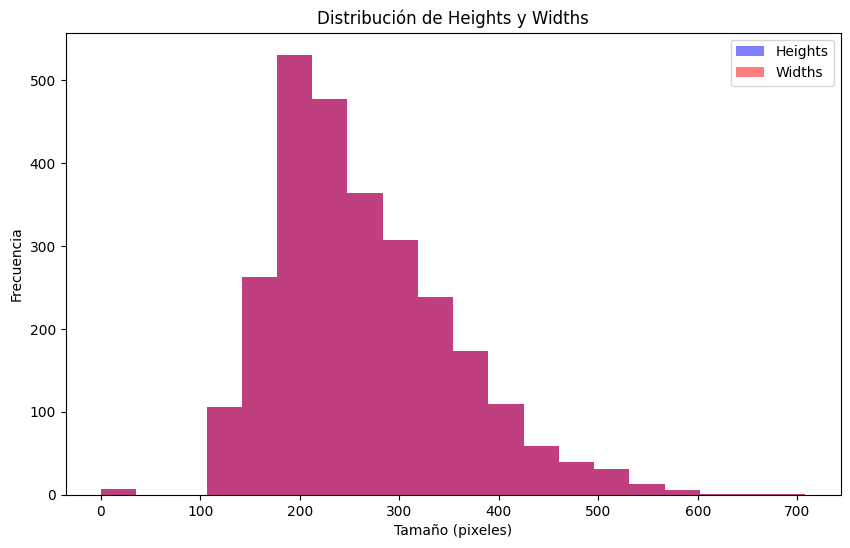

No se encontraron discrepancias entre height y width.


In [36]:
import csv
import ast
import matplotlib.pyplot as plt

# Leer el archivo CSV con las coordenadas corregidas
input_file = 'all_avcs_corrected_def.csv'

# Inicializar listas para almacenar alturas y anchos
heights = []
widths = []
discrepancies = []

# Función para calcular el ancho y la altura a partir de dos puntos
def calcular_dimensiones(p1, p2):
    x1, y1 = p1
    x2, y2 = p2
    ancho = abs(x2 - x1)
    altura = abs(y2 - y1)
    return ancho, altura

# Leer el archivo CSV y procesar las dimensiones
with open(input_file, 'r') as csvfile:
    reader = csv.DictReader(csvfile)
    
    for row in reader:
        # Procesar las coordenadas p1_new y p2_new
        p1_new = ast.literal_eval(row['p1_new'])
        p2_new = ast.literal_eval(row['p2_new'])

        # Calcular ancho y altura
        ancho, altura = calcular_dimensiones(p1_new, p2_new)

        # Almacenar en listas
        heights.append(altura)
        widths.append(ancho)

        if altura < 256:
            print(row['data'], row['subcarpeta'], row['carpeta paciente'], row['echo'], altura)
        # Verificar si hay discrepancia entre altura y ancho
        if ancho != altura:
            discrepancies.append((row['data'], row['subcarpeta'], row['carpeta paciente'], row['echo'], ancho, altura))

# Graficar la distribución de alturas y anchos
plt.figure(figsize=(10, 6))
plt.hist(heights, bins=20, alpha=0.5, label='Heights', color='blue')
plt.hist(widths, bins=20, alpha=0.5, label='Widths', color='red')
plt.title('Distribución de Heights y Widths')
plt.xlabel('Tamaño (pixeles)')
plt.ylabel('Frecuencia')
plt.legend(loc='upper right')
plt.show()

# Imprimir las discrepancias si las hay
if discrepancies:
    print("Discrepancias encontradas entre height y width:")
    for data, echo, ancho, altura in discrepancies:
        print(f"Data: {data}, Echo: {echo}, Width: {ancho}, Height: {altura}")
else:
    print("No se encontraron discrepancias entre height y width.")


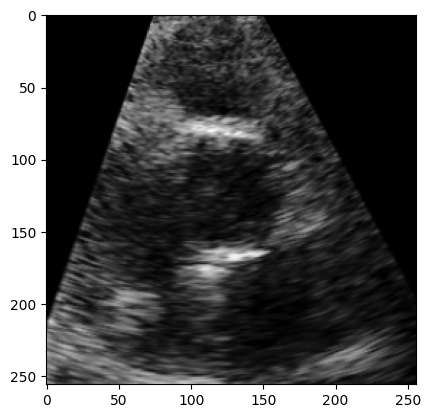

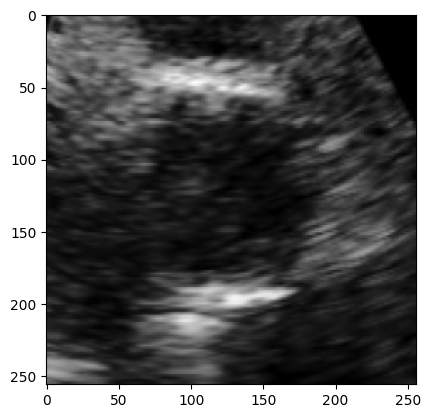

In [39]:
path = r"\\NAS3_Z\all\BKP_PERE\valveDetection\data\frames_valve\256_256\basal\10_010\IM_0015\frame_0015.npy"
frame = np.load(path)
plt.figure()
plt.imshow(frame, cmap='gray')
path = r"\\NAS3_Z\all\BKP_PERE\valveDetection\data\frames_valve\256_256_new\basal\10_010\IM_0015\frame_0015.npy"
frame = np.load(path)
plt.figure()
plt.imshow(frame, cmap='gray')

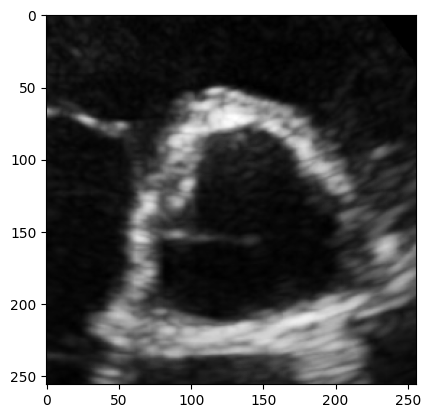

In [43]:
path = r"\\NAS3_Z\all\BKP_PERE\valveDetection\data\frames_valve\256_256_new\48m\1_062\14976913.Seq12.Ser0.Img1\frame_0024.npy"
frame = np.load(path)
plt.figure()
plt.imshow(frame, cmap='gray')